# Pull Arxiv papers utilizing Arxiv API

In [152]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import arxiv
from datetime import datetime, timedelta

In [153]:
client = arxiv.Client(
  page_size = 500,
  delay_seconds = 10.0,
  num_retries = 5
)

In [154]:
end = datetime.now()
start = end - timedelta(days=365)

start_str = start.strftime('%Y%m%d')
end_str = end.strftime('%Y%m%d')

search = arxiv.Search(
    query=f"(cat:cs.LG OR cat:cs.AI OR cat:cs.CL OR cat:cs.CV OR cat:cs.NE OR cat:cs.IR) AND submittedDate:[{start_str} TO {end_str}]",
    max_results=10000
)

results = client.results(search)

df = pd.DataFrame([{
    "id": result.get_short_id().split("v")[0],
    "title": result.title.strip(),
    "first_author": result.authors[0].name if result.authors else None,
    "authors": [a.name for a in result.authors] if result.authors else [],
    "published": result.published,
    "updated": result.updated,
    "primary_category": result.primary_category,
    "categories": result.categories if result.categories else [],
    "abstract": result.summary.strip() if result.summary else None,
    "link_url": result.entry_id or None,
    "pdf_url": result.pdf_url
} for result in results])

In [155]:
print(df.shape)
print(df.dtypes)
df.sort_values(by="published", inplace=True, ignore_index=True)
df

(10000, 11)
id                                  str
title                               str
first_author                        str
authors                          object
published           datetime64[us, UTC]
updated             datetime64[us, UTC]
primary_category                    str
categories                       object
abstract                            str
link_url                            str
pdf_url                             str
dtype: object


,id,title,first_author,authors,published,updated,primary_category,categories,abstract,link_url,pdf_url
0,2505.09901,Comparing Exploration-Exploitation Strategies ...,Ziyuan Zhang,"[Ziyuan Zhang, Darcy Wang, Ningyuan Chen, Rodr...",2025-05-15 02:09:18+00:00,2026-05-01 17:47:39+00:00,cs.LG,"[cs.LG, cs.AI, cs.CL, cs.HC]",Large language models (LLMs) are increasingly ...,http://arxiv.org/abs/2505.09901v3,https://arxiv.org/pdf/2505.09901v3
1,2505.09907,Avocado Price Prediction Using a Hybrid Deep L...,Linwei Zhang,"[Linwei Zhang, LuFeng, Ruijia Liang]",2025-05-15 02:26:22+00:00,2025-05-15 02:26:22+00:00,cs.LG,"[cs.LG, cs.AI, cs.CE]","With the growing demand for healthy foods, agr...",http://arxiv.org/abs/2505.09907v1,https://arxiv.org/pdf/2505.09907v1
2,2505.09925,Reinforced Interactive Continual Learning via ...,Yutao Yang,"[Yutao Yang, Jie Zhou, Junsong Li, Qianjun Pan...",2025-05-15 03:22:03+00:00,2025-05-15 03:22:03+00:00,cs.LG,"[cs.LG, cs.AI]",This paper introduces an interactive continual...,http://arxiv.org/abs/2505.09925v1,https://arxiv.org/pdf/2505.09925v1
3,2505.09935,VRU-CIPI: Crossing Intention Prediction at Int...,Ahmed S. Abdelrahman,"[Ahmed S. Abdelrahman, Mohamed Abdel-Aty, Quoc...",2025-05-15 03:40:29+00:00,2025-05-15 03:40:29+00:00,cs.CV,"[cs.CV, cs.AI, cs.LG]",Understanding and predicting human behavior in...,http://arxiv.org/abs/2505.09935v1,https://arxiv.org/pdf/2505.09935v1
4,2505.09945,Personalizing Large Language Models using Retr...,Deeksha Prahlad,"[Deeksha Prahlad, Chanhee Lee, Dongha Kim, Hok...",2025-05-15 04:01:58+00:00,2025-05-15 04:01:58+00:00,cs.CL,"[cs.CL, cs.AI, cs.LG]",The advent of large language models (LLMs) has...,http://arxiv.org/abs/2505.09945v1,https://arxiv.org/pdf/2505.09945v1
...,...,...,...,...,...,...,...,...,...,...,...
9995,2605.15156,MeMo: Memory as a Model,Ryan Wei Heng Quek,"[Ryan Wei Heng Quek, Sanghyuk Lee, Alfred Wei ...",2026-05-14 17:51:34+00:00,2026-05-14 17:51:34+00:00,cs.CL,"[cs.CL, cs.AI, cs.LG]",Large language models (LLMs) achieve strong pe...,http://arxiv.org/abs/2605.15156v1,https://arxiv.org/pdf/2605.15156v1
9996,2605.15168,"Text Knows What, Tables Know When: Clinical Ti...",Sayantan Kumar,"[Sayantan Kumar, Shahriar Noroozizadeh, Juyong...",2026-05-14 17:55:27+00:00,2026-05-14 17:55:27+00:00,cs.CL,"[cs.CL, cs.AI, cs.LG, stat.ML]",Reconstructing precise clinical timelines is e...,http://arxiv.org/abs/2605.15168v1,https://arxiv.org/pdf/2605.15168v1
9997,2605.15171,Evidential Reasoning Advances Interpretable Re...,Chenyu Lian,"[Chenyu Lian, Hong-Yu Zhou, Jing Qin]",2026-05-14 17:56:07+00:00,2026-05-14 17:56:07+00:00,cs.CV,"[cs.CV, cs.AI, cs.LG]",Disease screening is critical for early detect...,http://arxiv.org/abs/2605.15171v1,https://arxiv.org/pdf/2605.15171v1
9998,2605.15188,FutureSim: Replaying World Events to Evaluate ...,Shashwat Goel,"[Shashwat Goel, Nikhil Chandak, Arvindh Arun, ...",2026-05-14 17:59:28+00:00,2026-05-14 17:59:28+00:00,cs.LG,"[cs.LG, cs.AI, cs.CL]",AI agents are being increasingly deployed in d...,http://arxiv.org/abs/2605.15188v1,https://arxiv.org/pdf/2605.15188v1


In [156]:
df['primary_category'].value_counts()

primary_category
cs.LG       2674
cs.CL       2445
cs.CV       2402
cs.AI        908
cs.IR        487
            ... 
math.CO        1
q-bio.OT       1
q-fin.GN       1
hep-ex         1
stat.AP        1
Name: count, Length: 67, dtype: int64

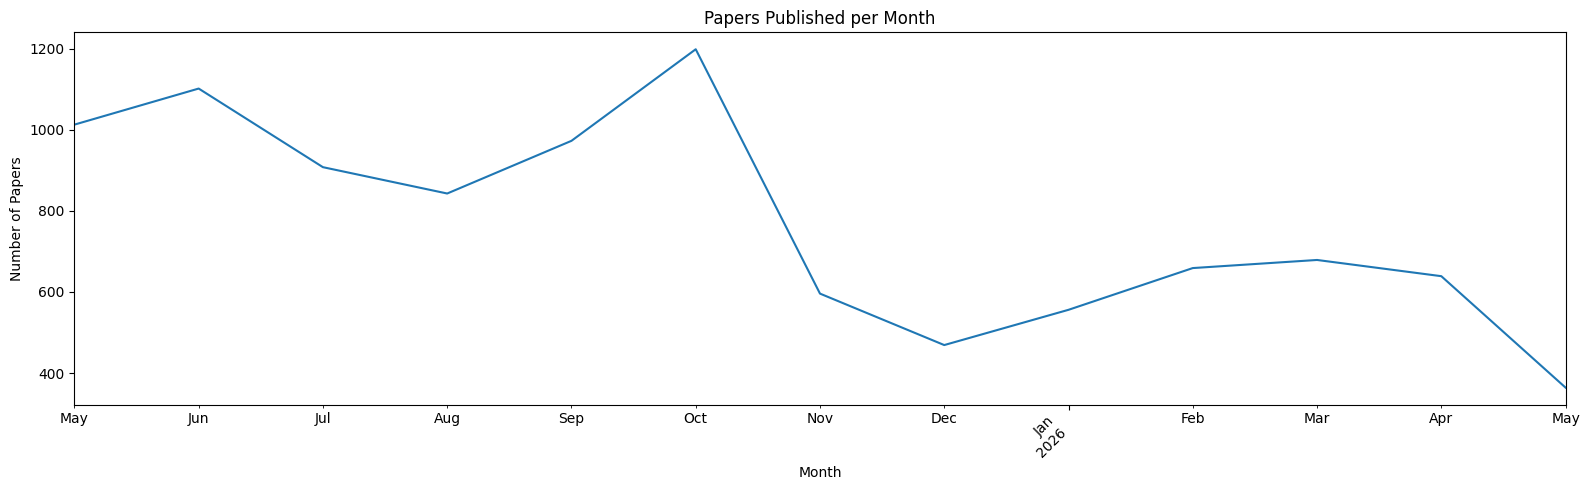

In [157]:
# convert to datetime if not already
df['published'] = pd.to_datetime(df['published']).dt.tz_localize(None)

# extract year-month and count
monthly_grouped = df.groupby(df['published'].dt.to_period('M')).size()

# plot
monthly_grouped.plot(kind='line', figsize=(16, 5))
plt.xlabel('Month')
plt.ylabel('Number of Papers')
plt.title('Papers Published per Month')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

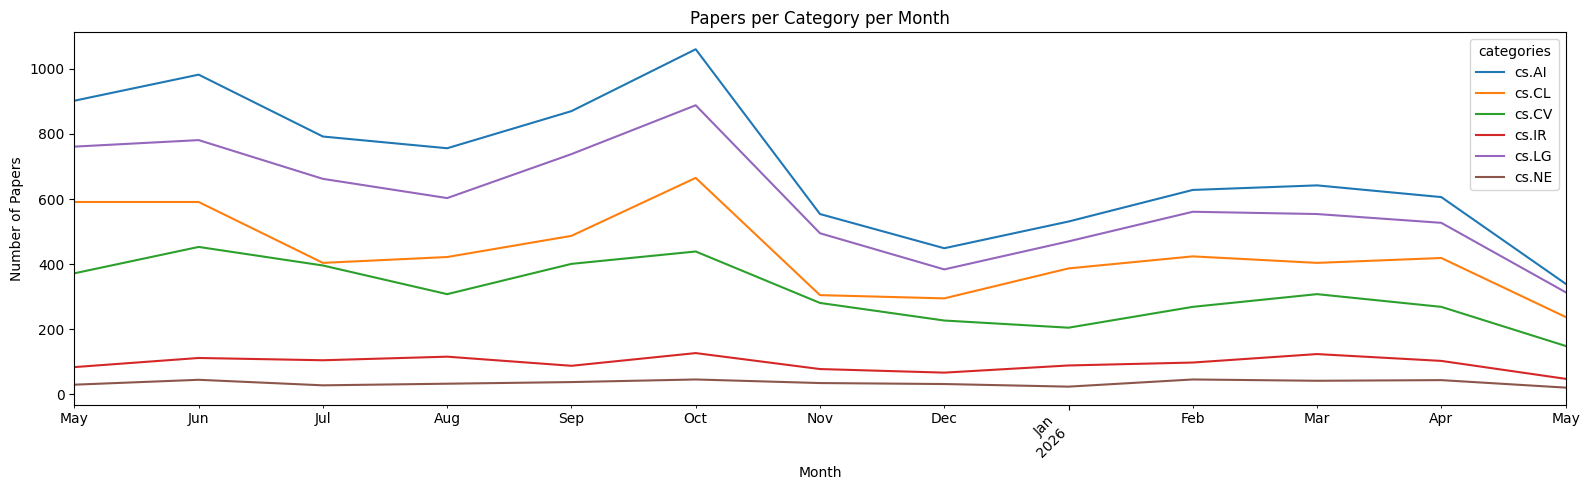

In [158]:
df_exploded = df.reset_index(drop=True).explode('categories')

main_categories = [
    "cs.LG",   # Machine Learning
    "cs.CV",   # Computer Vision
    "cs.CL",   # Computation & Language
    "cs.AI",   # Artificial Intelligence
    "cs.NE",   # Neural & Evolutionary Computing
    "cs.IR",   # Information Retrieval
]

filtered = df_exploded[df_exploded['categories'].isin(main_categories)].copy()

(
    filtered
    .groupby([filtered['published'].dt.to_period('M'), 'categories'])
    .size()
    .unstack('categories')
    .plot(figsize=(16, 5), title='Papers per Category per Month')
)

plt.xlabel('Month')
plt.ylabel('Number of Papers')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [159]:
df.to_csv("arxiv_papers.csv", index=False)